# PSI Thin-Limit Scan

Extract the 10 `PSI_thinlimit_1e7` runs, read the sample radius, height, and wall thickness from each `mccode.sim`, and compute the expected intensity in one spherical-monitor longitude bin using the same Born estimate as before:

`expected = intensity_hitting_sample * P_interact * solid_angle_bin / (4*pi)`


In [241]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Folder containing separately run thin-limit simulations.
# This can contain numeric run folders or named folders such as HST/PSI_1e-6.
run_root = Path('HST')
if not run_root.exists():
    run_root = Path('geometry_optimization/PSI_instrument/thinlimit/HST')

# Same constants/conventions used in PSI_instrument_plots.ipynb.
sigma_inc_cm_inv = 0.367
sigma_abs_cm_inv = sigma_inc_cm_inv
sigma_coh_cm_inv = 1.786e-3
sigma_total_cm_inv = sigma_inc_cm_inv + sigma_abs_cm_inv + sigma_coh_cm_inv
use_linear_probability = False
include_lids = True
# Lid thickness as a percentage of the cylindrical wall thickness.
lid_thickness_percent_of_wall = 95.0

latitude_halfwidth_deg = 2.0
# Exclude latitude bins with |latitude| > 90 - pole_cut_deg from corrected spherical plots.
pole_cut_deg = 30.0
apply_cosine_correction = True
cosine_floor = 1e-6
window_center_deg = 75.0
window_width_deg = 60.0

mask_direct_beam = True
direct_beam_center_spherical = (0.0, 0.0)
direct_beam_spherical_width_deg = 6.0
direct_beam_spherical_height_deg = 10.0

print(run_root.resolve())


/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/HST


In [242]:
def parse_mccode_params(sim_file):
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with Path(sim_file).open('r') as f:
        for line in f:
            match = pattern.match(line)
            if match:
                try:
                    params[match.group(1)] = float(match.group(2))
                except ValueError:
                    pass
    return params


def _parse_float_tuple(text, n):
    return tuple(float(value) for value in text.split(':', 1)[1].split()[:n])


def parse_mccode_dat(path):
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    meta = {'path': path}
    monitor_type = None
    nx = ny = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
            dim_match = re.search(r'array_(1d|2d)\(([^)]*)\)', monitor_type)
            if dim_match:
                dims = [int(value.strip()) for value in dim_match.group(2).split(',') if value.strip()]
                nx = dims[0] if dims else None
                ny = dims[1] if len(dims) > 1 else None
        elif line.startswith('# component:'):
            meta['component'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            meta['xlimits'] = _parse_float_tuple(line, 2)
        elif line.startswith('# xylimits:'):
            meta['xylimits'] = _parse_float_tuple(line, 4)
        elif line.startswith('# values:'):
            values = [float(value) for value in line.split(':', 1)[1].split()[:3]]
            meta['header_total'] = values[0]
            meta['header_error'] = values[1] if len(values) > 1 else np.nan
            meta['header_counts'] = values[2] if len(values) > 2 else np.nan

    data_start = None
    for index, line in enumerate(lines):
        if line.startswith('# Data') and line.rstrip().endswith('I:'):
            data_start = index + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find intensity section in {path}')

    rows = []
    for line in lines[data_start:]:
        stripped = line.strip()
        if stripped and not stripped.startswith('#'):
            rows.append([float(value) for value in stripped.split()])
    data = np.array(rows, dtype=float)

    if monitor_type and monitor_type.startswith('array_1d'):
        x = data[:, 0] if data.ndim == 2 and data.shape[1] >= 2 else np.arange(data.size)
        intensity = data[:, 1] if data.ndim == 2 and data.shape[1] >= 2 else data.reshape(-1)
        meta.update({'kind': '1d', 'x': x, 'I': intensity, 'total': float(np.nansum(intensity))})
        return meta

    intensity = data[:ny, :] if ny is not None and data.shape[0] >= ny else data
    error = data[ny:2 * ny, :] if ny is not None and data.shape[0] >= 2 * ny else None
    counts = data[2 * ny:3 * ny, :] if ny is not None and data.shape[0] >= 3 * ny else None
    meta.update({'kind': '2d', 'I': intensity, 'I_err': error, 'N': counts, 'total': float(np.nansum(intensity))})
    return meta


def record_total(record):
    return float(record.get('header_total', record['total']))


def record_total_error(record):
    if np.isfinite(record.get('header_error', np.nan)):
        return float(record['header_error'])
    if record.get('I_err') is not None:
        return float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float) ** 2)))
    return np.nan


def load_records(run_dir):
    records = {}
    for dat_file in Path(run_dir).glob('*.dat'):
        record = parse_mccode_dat(dat_file)
        records[dat_file.stem] = record
        if record.get('component'):
            records[record['component']] = record
    return records


def first_available_record(records, names):
    for name in names:
        if name in records:
            return records[name]
    raise KeyError(f'None of these records were found: {names}')


def coordinate_centers(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_y, n_x = record['I'].shape
    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)
    return 0.5 * (x_edges[:-1] + x_edges[1:]), 0.5 * (y_edges[:-1] + y_edges[1:]), x_edges, y_edges


In [243]:
def geometry_cm(run_dir):
    params = parse_mccode_params(Path(run_dir) / 'mccode.sim')
    return {
        'outer_radius_cm': params['sampleRadius'] * 100.0,
        'outer_height_cm': params['sampleHeight'] * 100.0,
        'wall_thickness_cm': params['sampleThickness'] * 100.0,
    }


def side_wall_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t = geometry['wall_thickness_cm']
    r = R - t
    if r <= 0:
        return np.nan
    return np.pi * (R**2 - r**2) * H


def lid_thickness_cm(geometry):
    return geometry['wall_thickness_cm'] * lid_thickness_percent_of_wall / 100.0


def lid_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    t_lid = lid_thickness_cm(geometry)
    if t_lid <= 0:
        return 0.0
    return 2.0 * np.pi * R**2 * t_lid


def sample_material_volume_cm3(geometry):
    volume = side_wall_volume_cm3(geometry)
    if include_lids:
        volume += lid_volume_cm3(geometry)
    return volume


def projected_area_cm2(geometry):
    return 2.0 * geometry['outer_radius_cm'] * geometry['outer_height_cm']


def mean_path_length_cm(geometry):
    return sample_material_volume_cm3(geometry) / projected_area_cm2(geometry)


def interaction_probability(geometry):
    length = mean_path_length_cm(geometry)
    if use_linear_probability:
        return sigma_inc_cm_inv * length
    total_probability = 1.0 - np.exp(-sigma_total_cm_inv * length)
    return total_probability * sigma_inc_cm_inv / sigma_total_cm_inv


def intensity_hitting_sample(records):
    before = records['sample_flux_before']
    after = records['sample_flux_after_unscattered']
    before_total = record_total(before)
    after_total = record_total(after)
    before_error = record_total_error(before)
    after_error = record_total_error(after)
    error = np.sqrt(before_error**2 + after_error**2) if np.isfinite(before_error) and np.isfinite(after_error) else np.nan
    return before_total - after_total, error, before_total, after_total


def valid_latitude_mask(record):
    _, lat_centers, _, _ = coordinate_centers(record)
    return np.abs(lat_centers) <= 90.0 - pole_cut_deg


def latitude_mask(record):
    _, lat_centers, _, _ = coordinate_centers(record)
    return (np.abs(lat_centers) <= latitude_halfwidth_deg) & valid_latitude_mask(record)


def corrected_band_solid_angle_per_longitude_sr(record, lat_mask):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_lat, n_lon = record['I'].shape
    dlon = np.deg2rad((x_max - x_min) / n_lon)
    lat_edges = np.linspace(y_min, y_max, n_lat + 1)
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    omega = 0.0
    for i, use_bin in enumerate(lat_mask):
        if not use_bin:
            continue
        lat1 = np.deg2rad(lat_edges[i])
        lat2 = np.deg2rad(lat_edges[i + 1])
        bin_omega = dlon * (np.sin(lat2) - np.sin(lat1))
        if apply_cosine_correction:
            cos_lat = np.cos(np.deg2rad(lat_centers[i]))
            if abs(cos_lat) < cosine_floor:
                continue
            bin_omega /= cos_lat
        omega += bin_omega
    return float(omega)


def observed_latitude_band_profile(record, lat_mask):
    lon_centers, lat_centers, _, _ = coordinate_centers(record)
    image = np.asarray(record['I'], dtype=float).copy()
    error = None if record.get('I_err') is None else np.asarray(record['I_err'], dtype=float).copy()

    if mask_direct_beam:
        center_lon, center_lat = direct_beam_center_spherical
        lon_beam = np.abs(angular_delta_deg(lon_centers, center_lon)) <= direct_beam_spherical_width_deg / 2.0
        lat_beam = np.abs(lat_centers - center_lat) <= direct_beam_spherical_height_deg / 2.0
        beam_mask = np.outer(lat_beam, lon_beam)
        image[beam_mask] = np.nan
        if error is not None:
            error[beam_mask] = np.nan

    if apply_cosine_correction:
        cos_lat = np.cos(np.deg2rad(lat_centers))
        valid = np.abs(cos_lat) >= cosine_floor
        image[valid, :] /= cos_lat[valid, None]
        image[~valid, :] = np.nan
        if error is not None:
            error[valid, :] /= cos_lat[valid, None]
            error[~valid, :] = np.nan

    profile = np.nansum(image[lat_mask, :], axis=0)
    profile_error = None if error is None else np.sqrt(np.nansum(error[lat_mask, :] ** 2, axis=0))
    return lon_centers, profile, profile_error


def angular_delta_deg(values, center):
    return (values - center + 180.0) % 360.0 - 180.0


def symmetric_window_mask(longitude):
    half_width = window_width_deg / 2.0
    positive = np.abs(angular_delta_deg(longitude, window_center_deg)) <= half_width
    negative = np.abs(angular_delta_deg(longitude, -window_center_deg)) <= half_width
    return positive | negative


def expected_intensity_for_run(run_dir):
    records = load_records(run_dir)
    spherical = first_available_record(records, ('sample_spherical_monitor_scattered', 'sample_spherical_monitor'))
    geometry = geometry_cm(run_dir)
    hit, hit_error, before, after = intensity_hitting_sample(records)
    lat_mask = latitude_mask(spherical)
    omega = corrected_band_solid_angle_per_longitude_sr(spherical, lat_mask)
    probability = interaction_probability(geometry)
    expected = hit * probability * omega / (4.0 * np.pi)

    longitude, profile, profile_error = observed_latitude_band_profile(spherical, lat_mask)
    lon_mask = symmetric_window_mask(longitude)
    observed_mean = float(np.nanmean(profile[lon_mask]))
    observed_mean_error = np.nan
    if profile_error is not None:
        observed_mean_error = float(np.sqrt(np.nansum(profile_error[lon_mask] ** 2)) / np.count_nonzero(lon_mask))

    run_dir = Path(run_dir)

    return {
        'run': run_dir.name,
        'run_dir': str(run_dir),
        'radius_cm': geometry['outer_radius_cm'],
        'height_cm': geometry['outer_height_cm'],
        'thickness_cm': geometry['wall_thickness_cm'],
        'lid_thickness_cm': lid_thickness_cm(geometry) if include_lids else 0.0,
        'side_wall_volume_cm3': side_wall_volume_cm3(geometry),
        'lid_volume_cm3': lid_volume_cm3(geometry) if include_lids else 0.0,
        'material_volume_cm3': sample_material_volume_cm3(geometry),
        'mean_path_cm': mean_path_length_cm(geometry),
        'P_interact': probability,
        'I_before': before,
        'I_after_unscattered': after,
        'I_hit': hit,
        'I_hit_err': hit_error,
        'solid_angle_per_lon_bin_sr': omega,
        'expected_per_lon_bin': expected,
        'observed_window_mean_per_lon_bin': observed_mean,
        'observed_window_mean_err': observed_mean_error,
        'observed_over_expected': observed_mean / expected if expected > 0 else np.nan,
        'n_window_bins': int(np.count_nonzero(lon_mask)),
    }


In [244]:
def discover_run_dirs(root):
    root = Path(root)
    run_dirs = sorted({path.parent for path in root.rglob('mccode.sim')})
    return sorted(run_dirs, key=lambda path: (geometry_cm(path)['wall_thickness_cm'], str(path)))


run_dirs = discover_run_dirs(run_root)
rows = []
for run_dir in run_dirs:
    try:
        rows.append(expected_intensity_for_run(run_dir))
    except Exception as exc:
        print(f'Skipping {run_dir}: {exc}')

results = pd.DataFrame(rows).sort_values('thickness_cm').reset_index(drop=True)
if results.empty:
    raise ValueError(f'No usable runs found under {run_root.resolve()}')

display(results)

print(f'Run root: {run_root.resolve()}')
print(f'Runs: {len(results)}')
print(f"Radius: {results['radius_cm'].iloc[0]:.6g} cm")
print(f"Height: {results['height_cm'].iloc[0]:.6g} cm")
print(f"Thickness range: {results['thickness_cm'].min():.6g} to {results['thickness_cm'].max():.6g} cm")
print(f"Include lids: {include_lids}")
print(f"Lid thickness: {lid_thickness_percent_of_wall:g}% of wall thickness")
print(f"Solid angle per longitude bin: {results['solid_angle_per_lon_bin_sr'].iloc[0]:.6g} sr")


,run,run_dir,radius_cm,height_cm,thickness_cm,lid_thickness_cm,side_wall_volume_cm3,lid_volume_cm3,material_volume_cm3,mean_path_cm,...,I_before,I_after_unscattered,I_hit,I_hit_err,solid_angle_per_lon_bin_sr,expected_per_lon_bin,observed_window_mean_per_lon_bin,observed_window_mean_err,observed_over_expected,n_window_bins
0,PSI_1e-6,HST/PSI_1e-6,1.0,1.0,0.0001,0.000095,0.000628,0.000597,0.001225,0.000613,...,55507400.0,42894300.0,12613100.0,12145.176650,0.002437,0.549764,0.536989,0.000956,0.976763,62
1,PSI_2e-6,HST/PSI_2e-6,1.0,1.0,0.0002,0.000190,0.001257,0.001194,0.002450,0.001225,...,55517800.0,42900600.0,12617200.0,12146.173676,0.002437,1.099609,1.066654,0.001830,0.970030,62
2,PSI_5e-6,HST/PSI_5e-6,1.0,1.0,0.0005,0.000475,0.003141,0.002985,0.006125,0.003063,...,55516000.0,42891100.0,12624900.0,12145.665081,0.002437,2.748631,2.614067,0.004051,0.951043,62
3,PSI_1e-5,HST/PSI_1e-5,1.0,1.0,0.0010,0.000950,0.006280,0.005969,0.012249,0.006125,...,55520900.0,42907400.0,12613500.0,12146.282936,0.002437,5.485414,5.050960,0.007036,0.920798,62
4,PSI_2e-5,HST/PSI_2e-5,1.0,1.0,0.0020,0.001900,0.012554,0.011938,0.024492,0.012246,...,55510800.0,42898000.0,12612800.0,12145.477249,0.002437,10.942763,9.653899,0.011920,0.882218,62
5,PSI_5e-5,HST/PSI_5e-5,1.0,1.0,0.0050,0.004750,0.031337,0.029845,0.061183,0.030591,...,55530400.0,42917300.0,12613100.0,12147.690696,0.002437,27.153107,21.807617,0.022076,0.803135,62


Run root: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/HST
Runs: 6
Radius: 1 cm
Height: 1 cm
Thickness range: 0.0001 to 0.005 cm
Include lids: True
Lid thickness: 95% of wall thickness
Solid angle per longitude bin: 0.00243682 sr


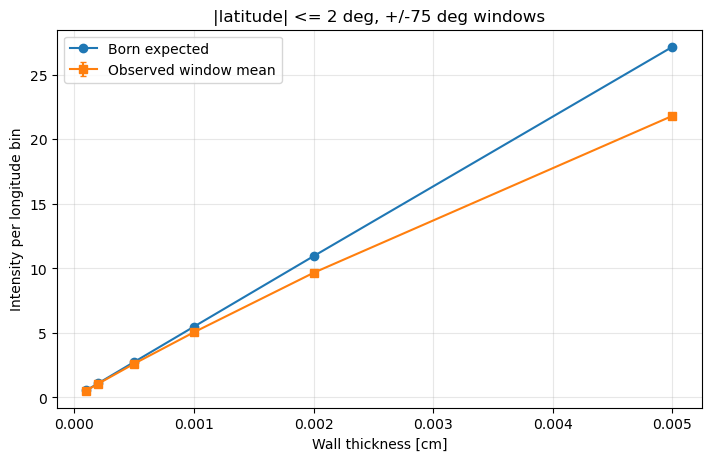

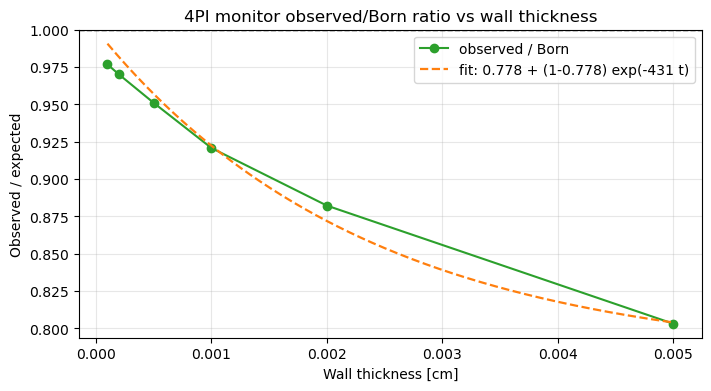

In [245]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(results['thickness_cm'], results['expected_per_lon_bin'], 'o-', label='Born expected')
ax.errorbar(
    results['thickness_cm'],
    results['observed_window_mean_per_lon_bin'],
    yerr=results['observed_window_mean_err'],
    fmt='s-',
    capsize=2,
    label='Observed window mean',
)
ax.set_xlabel('Wall thickness [cm]')
ax.set_ylabel('Intensity per longitude bin')
ax.set_title(f'|latitude| <= {latitude_halfwidth_deg:g} deg, +/-{window_center_deg:g} deg windows')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
fit_x = results['thickness_cm'].to_numpy(dtype=float)
fit_y = results['observed_over_expected'].to_numpy(dtype=float)
fit_mask = np.isfinite(fit_x) & np.isfinite(fit_y) & (fit_y > 0.0) & (fit_y <= 1.5)

ax.plot(fit_x, fit_y, 'o-', color='tab:green', label='observed / Born')
if fit_mask.sum() >= 2:
    # Fit ratio = c + (1 - c) * exp(-k * thickness).
    # For fixed c, k has a log-linear least-squares solution; scan c to avoid a SciPy dependency.
    x_fit = fit_x[fit_mask]
    y_fit = fit_y[fit_mask]
    c_max = min(0.999 * np.nanmin(y_fit), 0.999)
    c_grid = np.linspace(0.0, c_max, 2000)
    best = None
    for c_try in c_grid:
        transformed = (y_fit - c_try) / (1.0 - c_try)
        if np.any(transformed <= 0.0):
            continue
        log_transformed = np.log(transformed)
        k_try = -np.sum(x_fit * log_transformed) / np.sum(x_fit**2)
        if k_try < 0.0:
            continue
        pred = c_try + (1.0 - c_try) * np.exp(-k_try * x_fit)
        sse = np.sum((y_fit - pred)**2)
        if best is None or sse < best[0]:
            best = (sse, c_try, k_try)
    if best is not None:
        _, fit_c, fit_k = best
        fit_grid = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 300)
        fit_curve = fit_c + (1.0 - fit_c) * np.exp(-fit_k * fit_grid)
        ax.plot(
            fit_grid,
            fit_curve,
            color='tab:orange',
            linestyle='--',
            linewidth=1.6,
            label=f'fit: {fit_c:.3g} + (1-{fit_c:.3g}) exp(-{fit_k:.3g} t)',
        )
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Wall thickness [cm]')
ax.set_ylabel('Observed / expected')
ax.set_title('4PI monitor observed/Born ratio vs wall thickness')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.show()


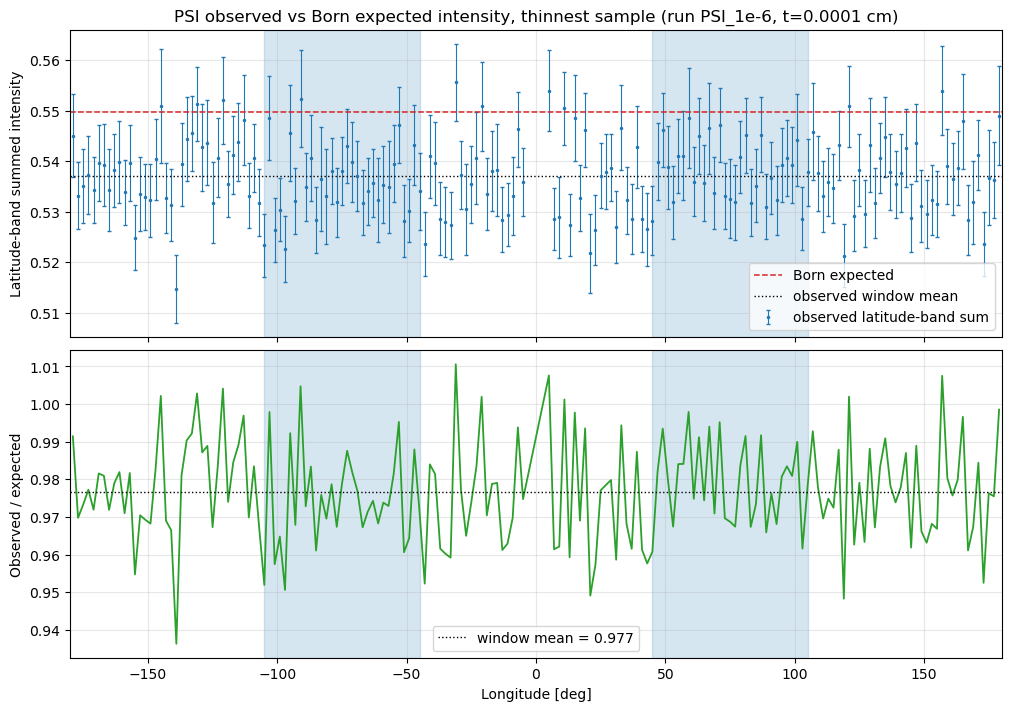

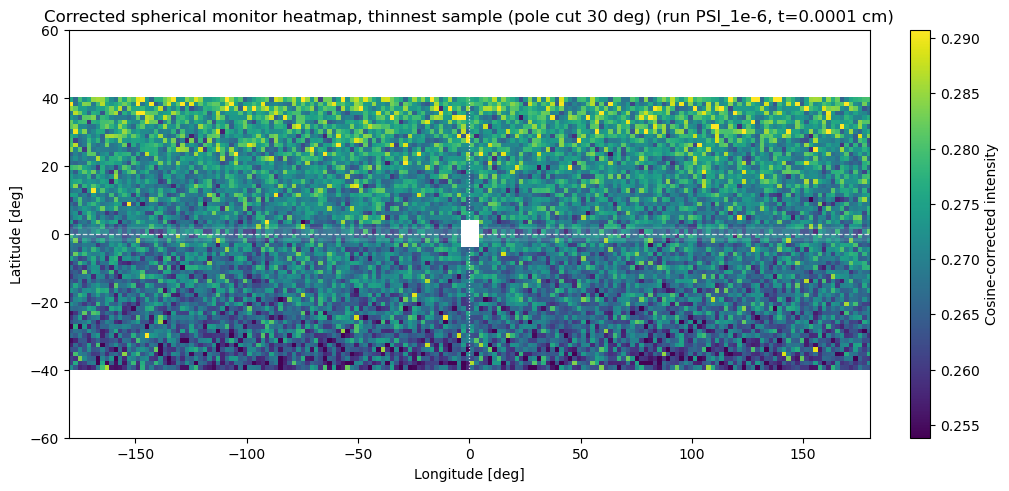

[1.00e-06 6.50e-06 1.20e-05 1.75e-05 2.30e-05 2.85e-05 3.40e-05 3.95e-05
 4.50e-05 5.05e-05 5.60e-05 6.15e-05 6.70e-05 7.25e-05 7.80e-05 8.35e-05
 8.90e-05 9.45e-05 1.00e-04]
[0.0002  0.00058 0.00096 0.00134 0.00172 0.0021  0.00248 0.00286 0.00324
 0.00362 0.004  ]


In [246]:
# Observed profile vs Born expected for the thinnest sample.
thinnest = results.loc[results['thickness_cm'].idxmin()]
thinnest_run_dir = Path(thinnest['run_dir'])
records = load_records(thinnest_run_dir)
spherical = first_available_record(records, ('sample_spherical_monitor_scattered', 'sample_spherical_monitor'))

lat_mask = latitude_mask(spherical)
longitude, profile, profile_error = observed_latitude_band_profile(spherical, lat_mask)
lon_mask = symmetric_window_mask(longitude)

expected = float(thinnest['expected_per_lon_bin'])
observed_mean = float(np.nanmean(profile[lon_mask]))
ratio = observed_mean / expected if expected > 0 else np.nan
valid = np.isfinite(profile) & (profile != 0.0)
ratio_values = np.full_like(profile, np.nan, dtype=float)
if expected > 0:
    ratio_values[valid] = profile[valid] / expected

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

if profile_error is not None:
    axs[0].errorbar(
        longitude[valid],
        profile[valid],
        yerr=profile_error[valid],
        fmt='.',
        markersize=3,
        linewidth=0.8,
        capsize=1.5,
        label='observed latitude-band sum',
    )
else:
    axs[0].plot(longitude[valid], profile[valid], '.', markersize=3, label='observed latitude-band sum')

for ax in axs:
    ax.axvspan(window_center_deg - window_width_deg / 2, window_center_deg + window_width_deg / 2, alpha=0.18, color='tab:blue')
    ax.axvspan(-window_center_deg - window_width_deg / 2, -window_center_deg + window_width_deg / 2, alpha=0.18, color='tab:blue')

axs[0].axhline(expected, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
axs[0].axhline(observed_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
axs[0].set_title(
    'PSI observed vs Born expected intensity, thinnest sample '
    f'(run {thinnest["run"]}, t={thinnest["thickness_cm"]:.6g} cm)'
)
axs[0].set_ylabel('Latitude-band summed intensity')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='best')

axs[1].plot(longitude[valid], ratio_values[valid], color='tab:green', lw=1.3)
axs[1].axhline(ratio, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio:.3g}')
axs[1].set_xlabel('Longitude [deg]')
axs[1].set_ylabel('Observed / expected')
axs[1].set_xlim(-180, 180)
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='best')
plt.show()

# Corrected heatmap for the thinnest sample, using the same masking/correction as the profile.
lon_centers, lat_centers, lon_edges, lat_edges = coordinate_centers(spherical)
corrected_image = np.asarray(spherical['I'], dtype=float).copy()

if mask_direct_beam:
    center_lon, center_lat = direct_beam_center_spherical
    lon_beam = np.abs(angular_delta_deg(lon_centers, center_lon)) <= direct_beam_spherical_width_deg / 2.0
    lat_beam = np.abs(lat_centers - center_lat) <= direct_beam_spherical_height_deg / 2.0
    corrected_image[np.outer(lat_beam, lon_beam)] = np.nan

if apply_cosine_correction:
    cos_lat = np.cos(np.deg2rad(lat_centers))
    cosine_valid = np.abs(cos_lat) >= cosine_floor
    corrected_image[cosine_valid, :] /= cos_lat[cosine_valid, None]
    corrected_image[~cosine_valid, :] = np.nan

valid_latitudes = valid_latitude_mask(spherical)
corrected_image[~valid_latitudes, :] = np.nan
display_lat_edges = lat_edges.copy()
display_lat_edges[0] = max(display_lat_edges[0], -90.0 + pole_cut_deg)
display_lat_edges[-1] = min(display_lat_edges[-1], 90.0 - pole_cut_deg)

vmin = np.nanpercentile(corrected_image, 1.0)
vmax = np.nanpercentile(corrected_image, 99.5)
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.imshow(
    corrected_image,
    origin='lower',
    aspect='auto',
    extent=[lon_edges[0], lon_edges[-1], display_lat_edges[0], display_lat_edges[-1]],
    interpolation='nearest',
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
)
ax.axhline(0.0, color='white', linestyle='--', linewidth=0.9, alpha=0.8)
ax.axvline(0.0, color='white', linestyle=':', linewidth=0.9, alpha=0.8)
ax.axhspan(-latitude_halfwidth_deg, latitude_halfwidth_deg, color='white', alpha=0.08)
ax.set_title(
    f'Corrected spherical monitor heatmap, thinnest sample (pole cut {pole_cut_deg:g} deg) '
    f'(run {thinnest["run"]}, t={thinnest["thickness_cm"]:.6g} cm)'
)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
fig.colorbar(im, ax=ax, label='Cosine-corrected intensity')
plt.show()

print(np.linspace(1e-6,1e-4, 19))
print(np.linspace(2e-4,4e-3, 11))
